<a href="https://colab.research.google.com/github/elijahmflomo/Sem_2_APPLIED-NATURAL-LANGUAGE-PROCESSING/blob/main/Assignment_Number_05_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sceniro 1:**

 Q: **TD(0) Policy Evaluation in a Grid World Environment**


The Intuition: What is TD(0)?

In Reinforcement Learning, Temporal Difference (TD) learning is like learning from a "glimpse into the future."
Instead of waiting until the robot reaches the goal to decide if its path was good (that’s Monte Carlo), the robot updates its estimate of a state's value immediately after every single step.

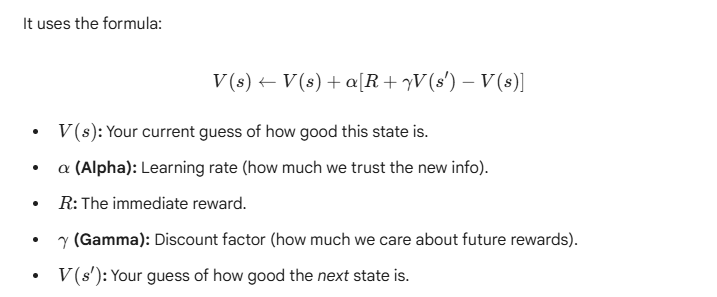

**Python Implementation**

I use numpy for the math and matplotlib/seaborn for the visuals.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 1. Environment Setup
GRID_SIZE = 4
GOAL_STATE = (3, 3)
START_STATE = (0, 0)
ACTIONS = ['up', 'down', 'left', 'right']
GAMMA = 0.95      # Discount factor
ALPHA = 0.1       # Learning rate
EPISODES = 500

# Initialize Value Table V(s) with zeros
V = np.zeros((GRID_SIZE, GRID_SIZE))

# To track the value of the start state for the learning curve
start_state_values = []

def get_next_state(state, action):
    r, c = state
    if action == 'up': r = max(0, r - 1)
    elif action == 'down': r = min(GRID_SIZE - 1, r + 1)
    elif action == 'left': c = max(0, c - 1)
    elif action == 'right': c = min(GRID_SIZE - 1, c + 1)
    return (r, c)


In [6]:
# 2. TD(0) Learning Loop
for ep in range(EPISODES):
    state = START_STATE

    while state != GOAL_STATE:
        # Random Policy: Pick an action at random
        action = np.random.choice(ACTIONS)
        next_state = get_next_state(state, action)

        # Determine reward
        reward = 10 if next_state == GOAL_STATE else -1

        # TD(0) Update Rule
        # V(s) = V(s) + alpha * [Reward + gamma * V(s') - V(s)]
        td_target = reward + GAMMA * V[next_state]
        td_error = td_target - V[state]
        V[state] += ALPHA * td_error

        state = next_state

    # Store the value of the start state after each episode
    start_state_values.append(V[START_STATE])

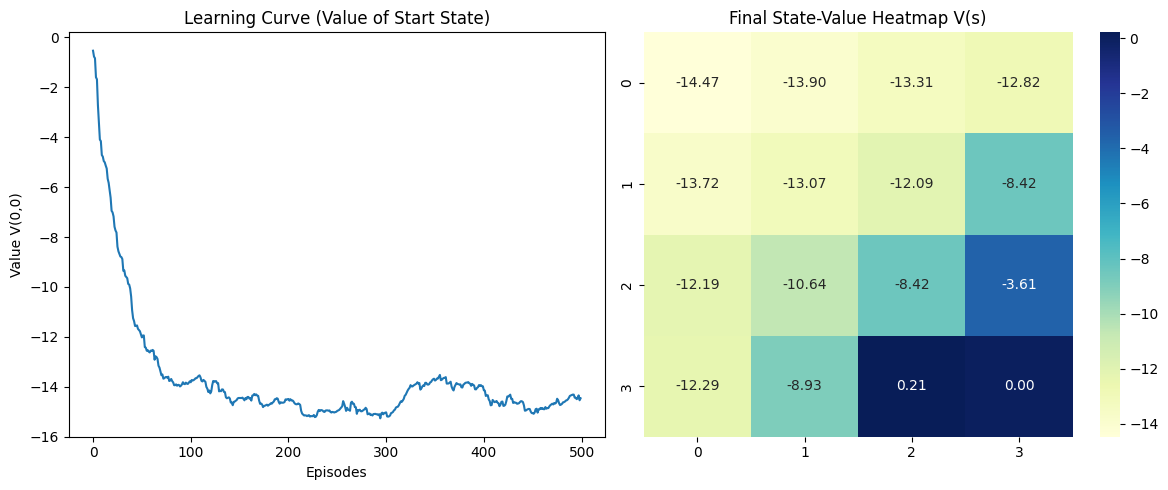

In [7]:
# 3. Visualization
plt.figure(figsize=(12, 5))

# Plot Learning Curve
plt.subplot(1, 2, 1)
plt.plot(start_state_values)
plt.title("Learning Curve (Value of Start State)")
plt.xlabel("Episodes")
plt.ylabel("Value V(0,0)")

# Plot Heatmap
plt.subplot(1, 2, 2)
sns.heatmap(V, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Final State-Value Heatmap V(s)")

plt.tight_layout()
plt.show()

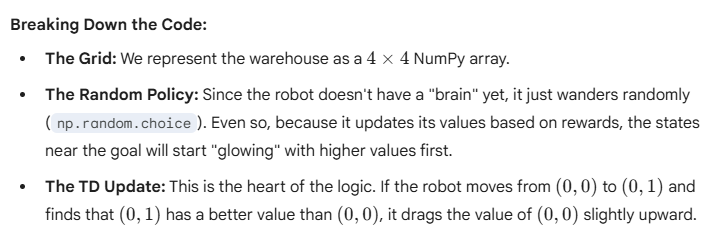

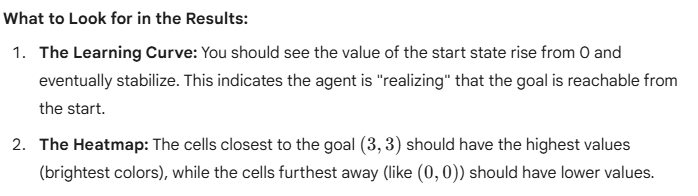

**Sceniro 2**


Q: The Intuition: What is SARSA?

SARSA stands for State, Action, Reward, State, Action. It is an on-policy algorithm. This means the robot learns the value of the policy it is actually following, including its random "exploration" moves.Because SARSA is on-policy, it is "cautious." In Cliff Walking, SARSA will learn to stay far away from the cliff edge because it knows that its epsilon -greedy policy might accidentally make it fall in.

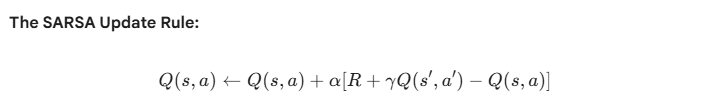

**Step-by-Step Python Implementation**
I will use a Q-Table: a dictionary or array that stores the "score" for every possible (State, Action) pair.

In [8]:
# 1. Environment Parameters
ROWS, COLS = 4, 12
START = (3, 0)
GOAL = (3, 11)
CLIFF = [(3, i) for i in range(1, 11)]

# Hyperparameters
ALPHA = 0.5       # Learning rate
GAMMA = 1.0       # Discount factor (usually 1.0 for episodic tasks)
EPSILON = 0.1     # Exploration rate
EPISODES = 1000

# Actions: 0=Up, 1=Down, 2=Left, 3=Right
ACTIONS = [0, 1, 2, 3]
Q_table = np.zeros((ROWS, COLS, len(ACTIONS)))

def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(ACTIONS)  # Explore
    else:
        return np.argmax(Q_table[state])  # Exploit (Greedy)

def get_next_state(state, action):
    r, c = state
    if action == 0: r = max(0, r - 1)    # Up
    elif action == 1: r = min(ROWS - 1, r + 1) # Down
    elif action == 2: c = max(0, c - 1)  # Left
    elif action == 3: c = min(COLS - 1, c + 1) # Right

    next_state = (r, c)
    if next_state in CLIFF:
        return START, -100
    if next_state == GOAL:
        return next_state, 0 # Usually 0 or positive, problem says -1 for steps
    return next_state, -1



In [9]:
# 2. SARSA Algorithm
reward_history = []

for ep in range(EPISODES):
    state = START
    action = choose_action(state, EPSILON)
    total_reward = 0

    while state != GOAL:
        next_state, reward = get_next_state(state, action)
        next_action = choose_action(next_state, EPSILON)

        # SARSA Update
        td_target = reward + GAMMA * Q_table[next_state][next_action]
        Q_table[state][action] += ALPHA * (td_target - Q_table[state][action])

        state, action = next_state, next_action
        total_reward += reward

    reward_history.append(total_reward)



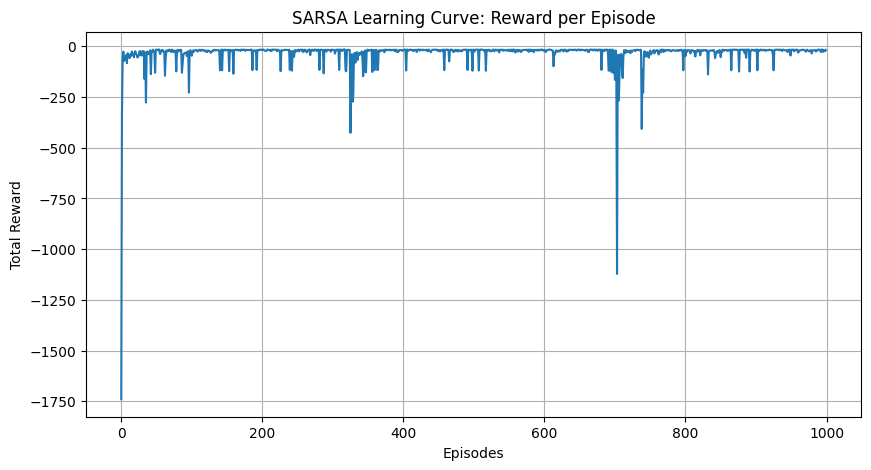


Learned Optimal Policy (SARSA):
→ | → | → | → | → | → | → | → | → | → | ↓ | ↓
→ | ↑ | ↑ | ← | → | ↑ | ↑ | ↑ | → | → | → | ↓
→ | ↑ | ← | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↓
↑ | C | C | C | C | C | C | C | C | C | C | G


In [10]:
# 3. Visualization
plt.figure(figsize=(10, 5))
plt.plot(reward_history)
plt.title("SARSA Learning Curve: Reward per Episode")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

# 4. Display Policy Map
policy_map = np.full((ROWS, COLS), " ")
arrows = {0: "↑", 1: "↓", 2: "←", 3: "→"}
for r in range(ROWS):
    for c in range(COLS):
        if (r, c) == GOAL: policy_map[r, c] = "G"
        elif (r, c) in CLIFF: policy_map[r, c] = "C"
        else:
            best_action = np.argmax(Q_table[r, c])
            policy_map[r, c] = arrows[best_action]

print("\nLearned Optimal Policy (SARSA):")
for row in policy_map:
    print(" | ".join(row))

**Sceniro 3**

Q: Implementation: Prediction vs. ControlWe'll use a $4 \times 4$ grid.

To make it interesting, we'll place the -5 penalties in a "bottleneck" that the agent must learn to navigate.

In [12]:
# 1. Environment Configuration
GRID_SIZE = 4
START = (0, 0)
GOAL = (3, 3)
PENALTIES = [(1, 1), (2, 2)]  # The "Trap" cells
ALPHA = 0.1
GAMMA = 0.9
EPSILON = 0.1
EPISODES = 500
ACTIONS = [0, 1, 2, 3] # Up, Down, Left, Right

# Initialize structures
V = np.zeros((GRID_SIZE, GRID_SIZE))          # For TD(0)
Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))       # For SARSA

def get_step(state, action):
    r, c = state
    if action == 0: r = max(0, r - 1)
    elif action == 1: r = min(GRID_SIZE - 1, r + 1)
    elif action == 2: c = max(0, c - 1)
    elif action == 3: c = min(GRID_SIZE - 1, c + 1)

    next_s = (r, c)
    if next_s == GOAL: return next_s, 20
    if next_s in PENALTIES: return next_s, -5
    return next_s, -1

# --- Task 1a: TD(0) Prediction (Using Random Policy) ---
td_rewards = []
for _ in range(EPISODES):
    s = START
    total_r = 0
    while s != GOAL:
        a = np.random.choice(ACTIONS)
        next_s, r = get_step(s, a)
        V[s] += ALPHA * (r + GAMMA * V[next_s] - V[s])
        s = next_s
        total_r += r
    td_rewards.append(total_r)

# --- Task 1b: SARSA Control (Using E-Greedy) ---
sarsa_rewards = []
for _ in range(EPISODES):
    s = START
    # Choose initial action
    a = np.argmax(Q[s]) if np.random.rand() > EPSILON else np.random.choice(ACTIONS)
    total_r = 0
    while s != GOAL:
        next_s, r = get_step(s, a)
        # Choose next action (On-policy)
        next_a = np.argmax(Q[next_s]) if np.random.rand() > EPSILON else np.random.choice(ACTIONS)

        # SARSA Update
        Q[s][a] += ALPHA * (r + GAMMA * Q[next_s][next_a] - Q[s][a])
        s, a = next_s, next_a
        total_r += r
    sarsa_rewards.append(total_r)



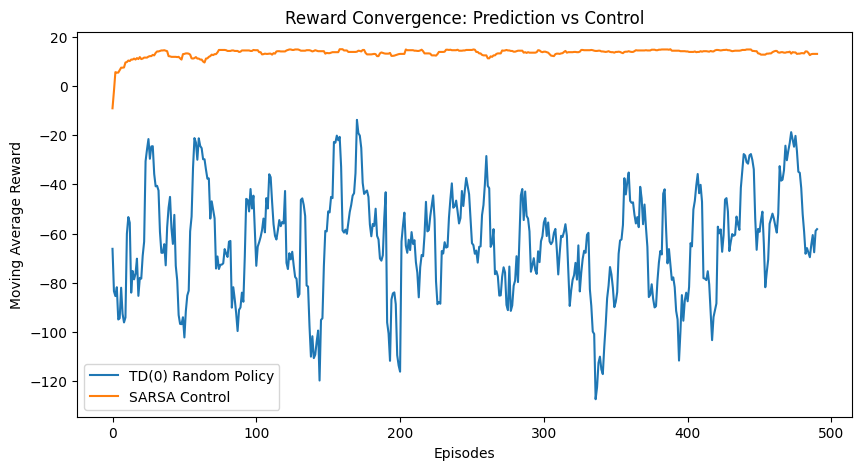

In [13]:
# 2. Comparison Visualization
plt.figure(figsize=(10, 5))
plt.plot(np.convolve(td_rewards, np.ones(10)/10, mode='valid'), label="TD(0) Random Policy")
plt.plot(np.convolve(sarsa_rewards, np.ones(10)/10, mode='valid'), label="SARSA Control")
plt.title("Reward Convergence: Prediction vs Control")
plt.xlabel("Episodes")
plt.ylabel("Moving Average Reward")
plt.legend()
plt.show()

 **Discussion: The Core Differences**

* Prediction (TD) is the process of estimating the value function for a fixed policy—it answers "How much reward will I get if I keep behaving this way?" Control (SARSA), however, uses those value estimates to constantly improve the policy. SARSA can directly learn an optimal policy because it updates Action-Values ($Q$) rather than just State-Values ($V$). By knowing which specific action leads to a better future, the agent can update its behavior (via $\epsilon$-greedy) to favor those actions, eventually converging on the path that maximizes the total reward.*